In [ ]:
!pip install tensorflow scikit-learn matplotlib

In [ ]:
# -*- coding: utf-8 -*-
"""
Red Neuronal TensorFlow + OECRS
Modo seleccionable:
- Dense clásica
- Capa Polinómica estable
"""

# ==========================================
# IMPORTS
# ==========================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback


# ==========================================
# 1. CONFIGURACIÓN
# ==========================================


"""
lista_x = []
lista_y = []
x = np.array(lista_x)
y = np.array(lista_y)
"""
x = np.linspace(-10, 10, 30)
y = (x-32)*(5/9)




import pandas as pd
import numpy as np

df = pd.read_csv("NASDAQ100_Historical_Data.csv")
df = df.sort_values("Date")        # aseguramos orden temporal
df = df.reset_index(drop=True)     # reseteamos índice
df["Date_ID"] = df.index           # creamos ID entero
x = df["Date_ID"].to_numpy()
y = df["Close"].to_numpy()
####################################
CONFIG = {
    "datos_x": x,
    "datos_y": y,
    "capas_ocultas": [20, 20],
    "activacion_oculta": "relu",
    "learning_rate": 0.01,
    "optimizer": "nesterov",
    "weight_decay": 0.0001,
    "batch_size": 32,
    "epochs": 5000,
    "OECRS_rounds": 0,
    "tipo_salida": "polynomial"  # "dense" o "polynomial"
}


# ==========================================
# 2. CAPA POLINÓMICA ESTABLE
# ==========================================
class StablePolynomialLayer(tf.keras.layers.Layer):
    def __init__(self, degree=3):
        super().__init__()
        self.degree = degree

    def build(self, input_shape):
        n_in = input_shape[-1]
        self.coeffs = self.add_weight(
            shape=(n_in, self.degree + 1),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(1,),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        powers = [x**i for i in range(self.degree + 1)]
        poly = tf.stack(powers, axis=-1)
        weighted = tf.reduce_sum(poly * self.coeffs, axis=[1,2])
        return tf.expand_dims(weighted, -1) + self.b


# ==========================================
# 3. CALLBACK LR
# ==========================================
class LRAvisador(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        if not hasattr(self, 'prev_lr'):
            self.prev_lr = lr
        if lr != self.prev_lr:
            print(f" -> [INFO] LR ajustado a: {lr:.6f} en época {epoch+1}")
            self.prev_lr = lr


# ==========================================
# 4. MOTOR DE CARACTERÍSTICAS
# ==========================================
def motor_de_caracteristicas(x, y):
    x_flat = x.flatten()
    y_flat = y.flatten()

    x_pos = np.where(x_flat <= 0, 1e-6, x_flat)

    transforms = {
        "lineal": x_flat,
        "cuadratica": x_flat**2,
        "logaritmica": np.log(x_pos),
        "exponencial": np.exp(np.clip(x_flat, -10, 10)),
        "inversa": 1 / x_pos,
        "raiz": np.sqrt(x_pos),
        "gaussiana": np.exp(-(x_flat**2))
    }

    correlaciones = {}
    for nombre, trans in transforms.items():
        corr = np.corrcoef(trans, y_flat)[0, 1]
        correlaciones[nombre] = 0 if np.isnan(corr) else abs(corr)

    mejor_patron = max(correlaciones, key=correlaciones.get)

    print("--- Análisis de Patrones ---")
    for k, v in correlaciones.items():
        print(f" > {k.capitalize()}: {v:.4f}")

    print(f"\nGanador: {mejor_patron.upper()}")

    x_final = np.hstack([x, transforms[mejor_patron].reshape(-1, 1)])
    return x_final, mejor_patron


# ==========================================
# 5. PREPROCESAMIENTO
# ==========================================
X_raw = CONFIG["datos_x"].reshape(-1, 1)
Y_raw = CONFIG["datos_y"].reshape(-1, 1)

X_features, patron_detectado = motor_de_caracteristicas(X_raw, Y_raw)

scaler_x, scaler_y = StandardScaler(), StandardScaler()
X_train = scaler_x.fit_transform(X_features)
y_train = scaler_y.fit_transform(Y_raw)


# ==========================================
# 6. CREAR MODELO
# ==========================================
def crear_modelo(n_in):

    if CONFIG["tipo_salida"] == "polynomial":
        print(">> Usando salida Polynomial")
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(n_in,)),
            StablePolynomialLayer(1)
        ])

    else:
        print(">> Usando salida Dense clásica")
        capas = [tf.keras.layers.Input(shape=(n_in,))]

        for n in CONFIG["capas_ocultas"]:
            capas.append(
                tf.keras.layers.Dense(n, activation=CONFIG["activacion_oculta"])
            )

        capas.append(tf.keras.layers.Dense(1, activation="linear"))

        model = tf.keras.Sequential(capas)

    # Crear optimizador una sola vez
    lr = CONFIG["learning_rate"]

    if CONFIG["optimizer"] == "nesterov":
        opt = tf.keras.optimizers.SGD(
            learning_rate=lr,
            momentum=0.9,
            nesterov=True,
            clipnorm=1.0
        )
    else:
        opt = tf.keras.optimizers.Adam(
            learning_rate=lr, clipnorm=1.0)

    model.compile(optimizer=opt, loss="mse", metrics=["mae"])

    return model


modelo = crear_modelo(X_train.shape[1])

--- Análisis de Patrones ---
 > Lineal: 0.3320
 > Cuadratica: 0.3521
 > Logaritmica: 0.2420
 > Exponencial: 0.0016
 > Inversa: 0.0006
 > Raiz: 0.3033
 > Gaussiana: 0.0007

Ganador: CUADRATICA
>> Usando salida Polynomial


In [ ]:
# ==========================================
# 7. ENTRENAMIENTO BASE
# ==========================================
callbacks = [
    EarlyStopping(monitor='loss', patience=50, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=15, min_lr=1e-6),
    LRAvisador()
]

print("\n--- Entrenando Red ---")

modelo.fit(
    X_train,
    y_train,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=0,
    callbacks=callbacks
)

print("Entrenamiento base completado.")



--- Entrenando Red ---
 -> [INFO] LR ajustado a: 0.005000 en época 37
 -> [INFO] LR ajustado a: 0.002500 en época 66
 -> [INFO] LR ajustado a: 0.001250 en época 82
 -> [INFO] LR ajustado a: 0.000625 en época 98
 -> [INFO] LR ajustado a: 0.000312 en época 121
 -> [INFO] LR ajustado a: 0.000156 en época 137
 -> [INFO] LR ajustado a: 0.000078 en época 152
 -> [INFO] LR ajustado a: 0.000039 en época 172
 -> [INFO] LR ajustado a: 0.000020 en época 187
 -> [INFO] LR ajustado a: 0.000010 en época 204
 -> [INFO] LR ajustado a: 0.000005 en época 219
 -> [INFO] LR ajustado a: 0.000002 en época 234
Entrenamiento base completado.


In [ ]:
# ==========================================
# 8. OECRS
# ==========================================
def evaluar_loss(model, X, y):
    loss, _ = model.evaluate(X, y, verbose=0)
    return loss


def reinicio_parcial(layer, fraccion=0.25):
    pesos = layer.get_weights()
    nuevos = []

    for w in pesos:
        std = np.std(w) + 1e-6
        mask = np.random.rand(*w.shape) < fraccion
        ruido = np.random.normal(0, std, w.shape)
        nuevos.append(np.where(mask, ruido, w))

    layer.set_weights(nuevos)


def optimizar_bloque_local(model, layer, X, y):
    for l in model.layers:
        l.trainable = False
    layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss="mse"
    )

    model.fit(X, y, epochs=40, batch_size=len(X), verbose=0)


def aplicar_OECRS(model, X, y, rondas):

    print("\n===== INICIANDO OECRS =====")

    loss_global = evaluar_loss(model, X, y)
    capas = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)]

    for ronda in range(rondas):
        print(f"\n--- Ronda {ronda+1}/{rondas} ---")

        for capa in capas:
            backup = capa.get_weights()

            reinicio_parcial(capa)
            optimizar_bloque_local(model, capa, X, y)

            loss_nuevo = evaluar_loss(model, X, y)

            if loss_nuevo < loss_global:
                print(f" ✔ Mejora: {loss_global:.6f} → {loss_nuevo:.6f}")
                loss_global = loss_nuevo
            else:
                capa.set_weights(backup)

    for l in model.layers:
        l.trainable = True

    model.compile(
        optimizer=model.optimizer,
        loss="mse",
        metrics=["mae"]
    )

    print("===== OECRS FINALIZADO =====")


aplicar_OECRS(modelo, X_train, y_train, CONFIG["OECRS_rounds"])


# ==========================================
# 9. PREDICCIÓN
# ==========================================
def predecir_inteligente(valor_usuario):

    x_input_raw = np.array([[float(valor_usuario)]])
    x_pos = np.where(x_input_raw <= 0, 1e-6, x_input_raw)

    trans_map = {
        "lineal": x_input_raw,
        "cuadratica": x_input_raw**2,
        "logaritmica": np.log(x_pos),
        "exponencial": np.exp(np.clip(x_input_raw, -10, 10)),
        "inversa": 1 / x_pos,
        "raiz": np.sqrt(x_pos),
        "gaussiana": np.exp(-(x_input_raw**2))
    }

    x_caracteristicas = np.hstack([
        x_input_raw,
        trans_map[patron_detectado].reshape(-1, 1)
    ])

    x_scaled = scaler_x.transform(x_caracteristicas)
    pred_scaled = modelo.predict(x_scaled, verbose=0)
    resultado = scaler_y.inverse_transform(pred_scaled)

    return resultado[0][0]


Entrada: 514078
Patrón: CUADRATICA
Predicción: 276.7365


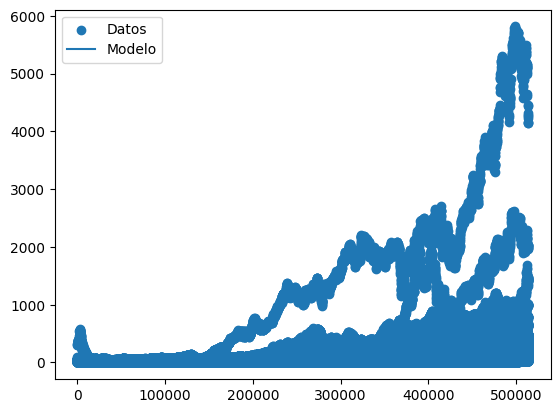

In [ ]:
# ==========================================
# 10. TEST
# ==========================================
valor = 514078
resultado = predecir_inteligente(valor)

print("\n" + "="*30)
print(f"Entrada: {valor}")
print(f"Patrón: {patron_detectado.upper()}")
print(f"Predicción: {resultado:.4f}")
print("="*30)


# ==========================================
# 11. GRÁFICA
# ==========================================
xs = np.linspace(-10, 10, 200)
preds = [predecir_inteligente(v) for v in xs]

plt.scatter(CONFIG["datos_x"], CONFIG["datos_y"], label="Datos")
plt.plot(xs, preds, label="Modelo")
plt.legend()
plt.show()